In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# 1) MORTALITY DATA
# -------------------------

mortality = pd.read_excel(
    "data/UNIGME-2025-UNICEFRegion-Rates-Deaths-Sex-specific-5-to-24.xlsx",
    sheet_name="20q5, 10q10",
    skiprows=14
)

mortality.columns = mortality.columns.str.strip()

mortality = mortality[["Region", "Sex", "Year", "Median"]]

mortality = mortality.rename(columns={
    "Median": "mort_median_5_24"
})

mortality["mort_median_5_24"] = pd.to_numeric(
    mortality["mort_median_5_24"],
    errors="coerce"
)

mortality = mortality.groupby(["Region", "Year"])["mort_median_5_24"].mean().reset_index()


# -------------------------
# 2) HDI DATA
# -------------------------

hdi = pd.read_excel(
    "data/HDR25_Statistical_Annex_HDI_Table.xlsx",
    skiprows=4,
    usecols="B:C"
)

hdi.columns = ["Country", "HDI"]
hdi = hdi.iloc[2:].reset_index(drop=True)

hdi["Country"] = hdi["Country"].astype(str).str.strip()
hdi["HDI"] = pd.to_numeric(hdi["HDI"], errors="coerce")


# -------------------------
# 3) ECONOMIC DATA
# -------------------------

econ = pd.read_excel(
    "data/19-Economic-Indicators-SOWC2025-1.xlsx",
    skiprows=6,
    header=None,
    usecols=[1, 6, 8]
)

econ.columns = ["Country", "health_spending", "education_spending"]
econ = econ.iloc[1:].reset_index(drop=True)

econ["Country"] = econ["Country"].astype(str).str.strip()
econ["health_spending"] = pd.to_numeric(econ["health_spending"], errors="coerce")
econ["education_spending"] = pd.to_numeric(econ["education_spending"], errors="coerce")


# -------------------------
# 4) REGION MAPPING
# -------------------------

mapping = pd.read_excel("data/JME_Regional-Classifications.xlsx")
mapping.columns = mapping.columns.str.strip()

mapping = mapping[["Country", "UNICEF Region"]]
mapping["Country"] = mapping["Country"].astype(str).str.strip()

region_map = {
    "EAPRO": "East Asia and Pacific",
    "ECA": "Europe and Central Asia",
    "LACRO": "Latin America and Caribbean",
    "MENA": "Middle East and North Africa",
    "ROSA": "South Asia",
    "SSA": "Sub-Saharan Africa"
}


# -------------------------
# 5) MERGE HDI + ECON WITH REGION
# -------------------------

hdi = hdi.merge(mapping, on="Country", how="left")
hdi = hdi.rename(columns={"UNICEF Region": "Region"})
hdi["Region"] = hdi["Region"].replace(region_map)

econ = econ.merge(mapping, on="Country", how="left")
econ = econ.rename(columns={"UNICEF Region": "Region"})
econ["Region"] = econ["Region"].replace(region_map)


# -------------------------
# 6) REGION-LEVEL AVERAGES
# -------------------------

hdi_region = hdi.groupby("Region")["HDI"].mean().reset_index()

econ_region = econ.groupby("Region")[["health_spending", "education_spending"]].mean().reset_index()


# -------------------------
# 7) FINAL DATAFRAME
# -------------------------

df = mortality.merge(hdi_region, on="Region", how="left")
df = df.merge(econ_region, on="Region", how="left")

df = df.dropna().reset_index(drop=True)

df.head()

,Region,Year,mort_median_5_24,HDI,health_spending,education_spending
0,East Asia and Pacific,1990,18.477822,0.735857,4.563424,4.522219
1,East Asia and Pacific,1991,18.001312,0.735857,4.563424,4.522219
2,East Asia and Pacific,1992,17.444175,0.735857,4.563424,4.522219
3,East Asia and Pacific,1993,16.978292,0.735857,4.563424,4.522219
4,East Asia and Pacific,1994,16.549464,0.735857,4.563424,4.522219


In [19]:
df.isnull().sum()

Region                0
Year                  0
mort_median_5_24      0
HDI                   0
health_spending       0
education_spending    0
dtype: int64

## Machine Learning Model

In this section, Linear Regression and KNN Regression models were used to predict youth mortality rates based on HDI, health spending, and education spending.

Linear Regression was used as a baseline model because it captures the global linear relationship between predictors and the target variable.

KNN Regression was also applied because it can capture more local patterns in the data. Since KNN is distance-based, feature scaling was applied using StandardScaler.

Model performance was evaluated using Mean Squared Error (MSE) and R² score. A lower MSE and higher R² indicate better predictive performance.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X_reg = df[["HDI", "health_spending", "education_spending"]]
y_reg = df["mort_median_5_24"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

linear_model = LinearRegression()
linear_model.fit(X_train_reg, y_train_reg)
y_pred_linear = linear_model.predict(X_test_reg)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reg)
X_test_scaled = scaler.transform(X_test_reg)

knn = KNeighborsRegressor(n_neighbors=10)
knn.fit(X_train_scaled, y_train_reg)
y_pred_knn = knn.predict(X_test_scaled)

baseline_pred = np.mean(y_train_reg)
baseline_preds = np.full(len(y_test_reg), baseline_pred)

print("Ready.")
print("Linear RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_linear)))
print("KNN RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_knn)))
print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test_reg, baseline_preds)))

print()

print("Linear R2:", r2_score(y_test_reg, y_pred_linear))
print("KNN R2:", r2_score(y_test_reg, y_pred_knn))
print("Baseline R2:", r2_score(y_test_reg, baseline_preds))

Ready.
Linear RMSE: 9.94414352592034
KNN RMSE: 7.677750936463734
Baseline RMSE: 16.655078490960765

Linear R2: 0.6431716296633285
KNN R2: 0.787287678255176
Baseline R2: -0.0009628888535988533


The KNN model outperforms both linear regression and the baseline model, achieving the lowest RMSE and highest R² score.

The predicted vs actual plot shows that most predictions align closely with the ideal diagonal, indicating a good fit.

However, the residual plot suggests increasing variance at higher predicted values, indicating potential heteroscedasticity and limitations in modeling extreme mortality values.

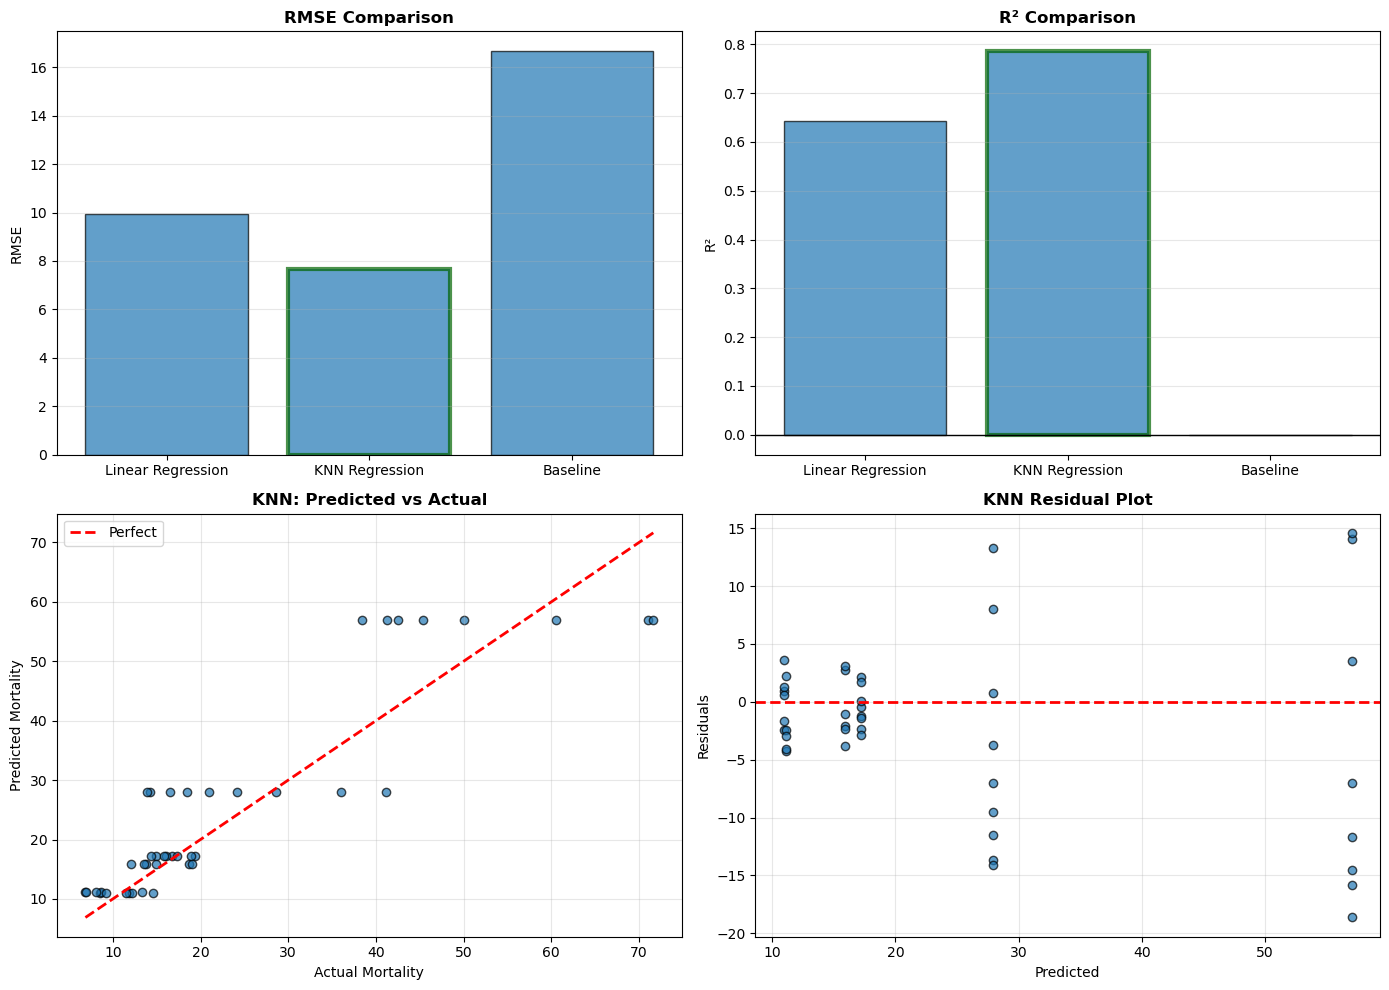

Saved: final_model_dashboard.png


In [21]:
import matplotlib.pyplot as plt

# ---- Metrics ----
models = ["Linear Regression", "KNN Regression", "Baseline"]

rmse_vals = [
    np.sqrt(mean_squared_error(y_test_reg, y_pred_linear)),
    np.sqrt(mean_squared_error(y_test_reg, y_pred_knn)),
    np.sqrt(mean_squared_error(y_test_reg, baseline_preds))
]

r2_vals = [
    r2_score(y_test_reg, y_pred_linear),
    r2_score(y_test_reg, y_pred_knn),
    r2_score(y_test_reg, baseline_preds)
]

# ---- Figure ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -------------------------
# 1) RMSE Comparison
# -------------------------
ax = axes[0, 0]

bars = ax.bar(models, rmse_vals, alpha=0.7, edgecolor="black")

best_idx = rmse_vals.index(min(rmse_vals))
bars[best_idx].set_edgecolor("darkgreen")
bars[best_idx].set_linewidth(3)

ax.set_title("RMSE Comparison", fontweight="bold")
ax.set_ylabel("RMSE")
ax.grid(axis="y", alpha=0.3)


# -------------------------
# 2) R² Comparison
# -------------------------
ax = axes[0, 1]

bars = ax.bar(models, r2_vals, alpha=0.7, edgecolor="black")

best_idx = r2_vals.index(max(r2_vals))
bars[best_idx].set_edgecolor("darkgreen")
bars[best_idx].set_linewidth(3)

ax.set_title("R² Comparison", fontweight="bold")
ax.set_ylabel("R²")
ax.axhline(0, color="black", linewidth=1)
ax.grid(axis="y", alpha=0.3)


# -------------------------
# 3) Predicted vs Actual (KNN)
# -------------------------
ax = axes[1, 0]

ax.scatter(y_test_reg, y_pred_knn, alpha=0.7, edgecolor="black")

min_val = min(y_test_reg.min(), y_pred_knn.min())
max_val = max(y_test_reg.max(), y_pred_knn.max())

ax.plot([min_val, max_val], [min_val, max_val],
        "r--", linewidth=2, label="Perfect")

ax.set_title("KNN: Predicted vs Actual", fontweight="bold")
ax.set_xlabel("Actual Mortality")
ax.set_ylabel("Predicted Mortality")
ax.legend()
ax.grid(alpha=0.3)


# -------------------------
# 4) Residual Plot (KNN)
# -------------------------
ax = axes[1, 1]

residuals = y_test_reg - y_pred_knn

ax.scatter(y_pred_knn, residuals, alpha=0.7, edgecolor="black")
ax.axhline(0, color="red", linestyle="--", linewidth=2)

ax.set_title("KNN Residual Plot", fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("Residuals")
ax.grid(alpha=0.3)


# ---- Final touches ----
plt.tight_layout()
plt.savefig("final_model_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: final_model_dashboard.png")

KNN regression outperforms linear regression in predicting youth mortality, as evidenced by its lower RMSE and higher R² score. This indicates that the relationship between development indicators (HDI, health spending, education spending) and youth mortality is likely non-linear, which KNN is better able to capture compared to linear regression.

**Residual Analysis**

The residual plot shows that prediction errors increase at higher mortality levels, suggesting that the model struggles to accurately predict extreme values. This may indicate the presence of additional unobserved factors, such as regional inequalities or socio-economic conditions, that are not captured by the current feature set.



Furthermore, the clustering pattern in residuals suggests heteroscedasticity, meaning the variance of errors is not constant across all prediction ranges.

In [22]:
baseline_pred = np.mean(y_train_reg)

baseline_preds = np.full_like(y_test_reg, baseline_pred)

print("Baseline MSE:", mean_squared_error(y_test_reg, baseline_preds))
print("Baseline R2:", r2_score(y_test_reg, baseline_preds))

Baseline MSE: 277.3916395400639
Baseline R2: -0.0009628888535988533


as you see from here, the KNN model performs substantially better than a simple mean baseline, indicating that HDI, health spending, and education spending contain meaningful predictive information about youth mortality.

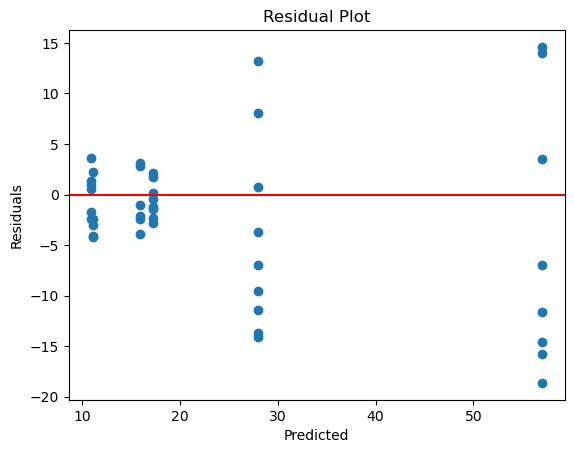

In [23]:
residuals = y_test_reg - y_pred_knn

plt.scatter(y_pred_knn, residuals)
plt.axhline(0, color='red')

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [24]:
coef_df = pd.DataFrame({
    "Feature": X_train_reg.columns,
    "Coefficient": linear_model.coef_
})

coef_df

,Feature,Coefficient
0,HDI,-139.899184
1,health_spending,0.285788
2,education_spending,0.379815


In [25]:
df[["HDI", "health_spending", "education_spending"]].corr()

,HDI,health_spending,education_spending
HDI,1.000000,0.888303,0.842585
health_spending,0.888303,1.000000,0.973844
education_spending,0.842585,0.973844,1.000000


The correlation matrix reveals strong multicollinearity between HDI, health spending, and education spending (correlations above 0.84).

This explains the unstable and disproportionately large coefficient assigned to HDI in the linear regression model.

Due to multicollinearity, coefficient interpretations are unreliable, even though the model may still achieve reasonable predictive performance.

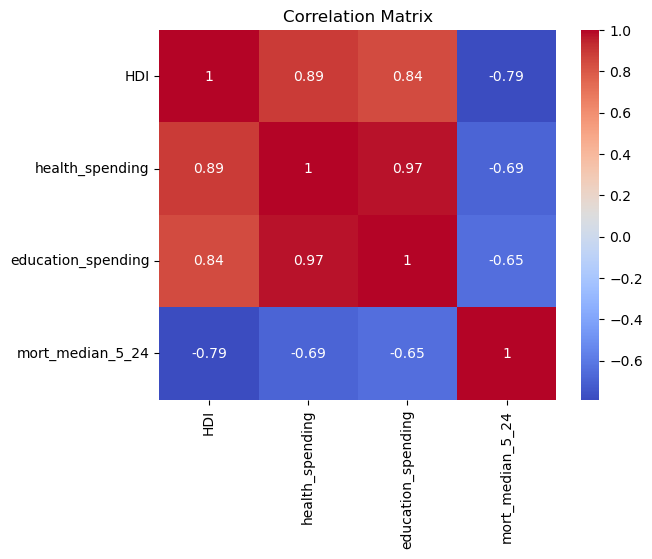

In [26]:
sns.heatmap(df[["HDI", "health_spending", "education_spending", "mort_median_5_24"]].corr(),

            annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

**HDI vs Mortality**
HDI shows a strong negative correlation with youth mortality (-0.79), indicating that higher development levels are associated with significantly lower mortality rates.
**Health & Education Spending** 
Higher public spending on health and education is associated with lower youth mortality, although the relationship is slightly weaker than HDI.

*MULTICOLLINEARITY*
There is strong multicollinearity among HDI, health spending, and education spending, suggesting that these variables capture overlapping aspects of development.
* health ↔ education = 0.97 (!!)
* HDI ↔ health = 0.89
* HDI ↔ education = 0.84

In [27]:
error_df = pd.DataFrame({
    "Actual": y_test_reg,
    "Predicted": y_pred_knn,
    "Error": y_test_reg - y_pred_knn
})

error_df.sort_values("Error", key=abs, ascending=False).head()

,Actual,Predicted,Error
207,38.397553,57.031324,-18.633771
199,41.239397,57.031324,-15.791927
180,71.633308,57.031324,14.601984
197,42.470698,57.031324,-14.560626
173,13.859599,27.937412,-14.077813


interpretation: The error analysis reveals that the model tends to regress toward the mean. It overestimates lower mortality values and underestimates higher ones.

This suggests that the KNN model struggles to capture extreme mortality cases, likely due to its reliance on local averaging.

The largest errors occur for high mortality observations, indicating that extreme cases are not well represented in the feature space.

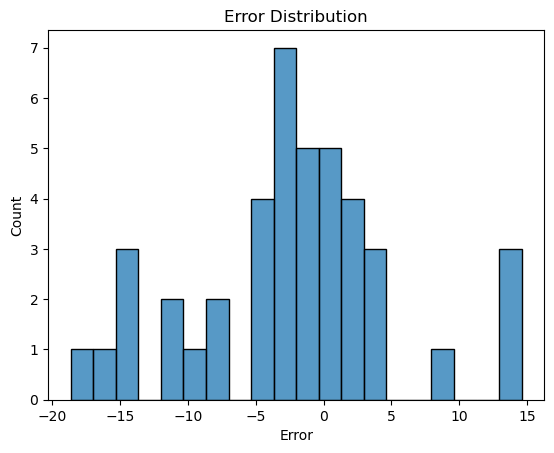

In [28]:
sns.histplot(error_df["Error"], bins=20)

plt.title("Error Distribution")

plt.show()

The error distribution is centered around zero, indicating that the model is not strongly biased overall.

However, the distribution is slightly skewed toward negative errors, suggesting a tendency to overestimate mortality in some cases.

Several large errors are present on both sides, indicating that the model struggles with extreme values.

The wide spread of errors suggests that prediction accuracy varies across observations, with reduced performance for certain cases.

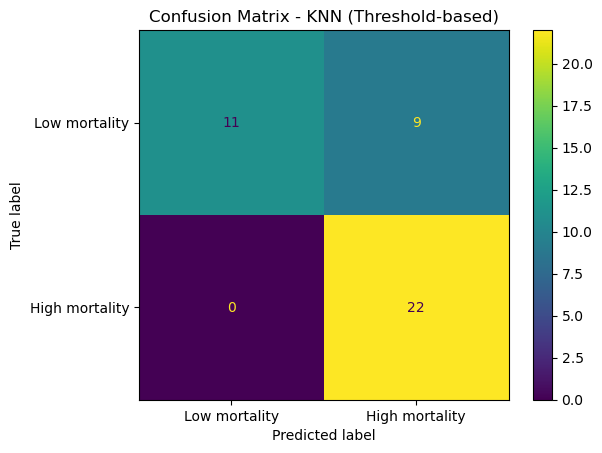

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# -------------------------
# 1) Threshold belirle
# -------------------------
threshold = y_train_reg.median()

# -------------------------
# 2) Gerçek değerleri sınıfa çevir
# -------------------------
y_test_class = (y_test_reg > threshold).astype(int)

# -------------------------
# 3) KNN tahminlerini sınıfa çevir
# -------------------------
y_pred_knn_class = (y_pred_knn > threshold).astype(int)

# -------------------------
# 4) Confusion Matrix
# -------------------------
ConfusionMatrixDisplay.from_predictions(
    y_test_class,
    y_pred_knn_class,
    display_labels=["Low mortality", "High mortality"],
    values_format="d"
)

plt.title("Confusion Matrix - KNN (Threshold-based)")
plt.show()

Since the original task is regression, a threshold-based transformation was applied to convert predictions into binary classes (high vs low mortality) to enable confusion matrix evaluation

## Unsupervised Part


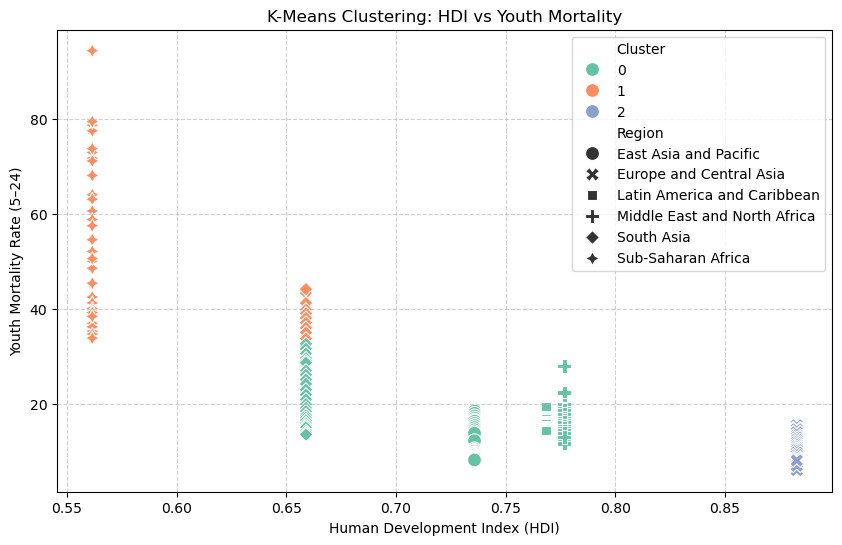

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Feature selection
features = ["HDI", "mort_median_5_24"]
X_cluster = df[features]

# 2) Scaling
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# 3) K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_cluster_scaled)

# 4) Visualization
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="HDI",
    y="mort_median_5_24",
    hue="Cluster",
    style="Region",
    palette="Set2",
    s=100
)

plt.title("K-Means Clustering: HDI vs Youth Mortality")
plt.xlabel("Human Development Index (HDI)")
plt.ylabel("Youth Mortality Rate (5–24)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

K-Means clustering was applied using HDI and youth mortality. Since these variables are measured on different scales, StandardScaler was applied before clustering.

The clustering results show a clear separation between low-HDI/high-mortality observations and high-HDI/low-mortality observations. This supports the idea that development level is strongly associated with both the level and variability of youth mortality.

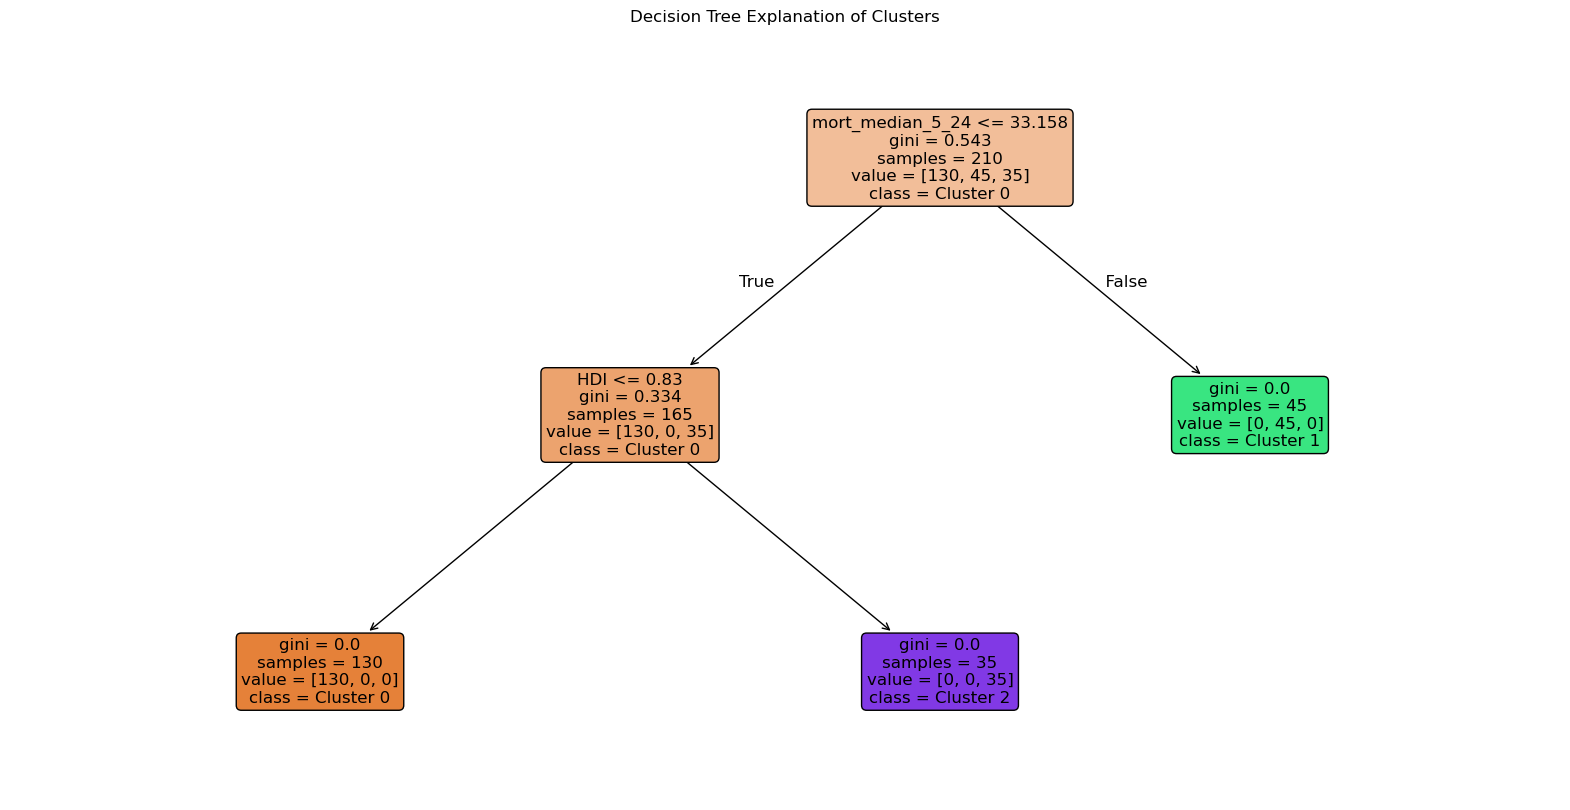

In [31]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# KMeans'te kullandığın feature'lar
features = ["HDI", "health_spending", "education_spending", "mort_median_5_24"]

X_tree = df[features]
y_tree = df["Cluster"]

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_tree, y_tree)

plt.figure(figsize=(20, 10))

plot_tree(
    clf,
    feature_names=features,
    class_names=["Cluster 0", "Cluster 1", "Cluster 2"],
    filled=True,
    rounded=True,
    fontsize=12
)

plt.title("Decision Tree Explanation of Clusters")
plt.show()

To better understand the clustering structure, a decision tree was trained to predict cluster assignments.

The tree reveals that clusters are primarily separated based on HDI thresholds, indicating that HDI is the dominant factor driving the clustering results. Other variables such as health and education spending play a relatively minor role in determining cluster membership.

This suggests that the clustering largely reflects underlying development levels rather than complex multi-dimensional patterns.

The decision tree indicates that youth mortality is the primary splitting factor, with HDI further refining cluster separation.

### Time-based Regression Analysis

To capture temporal patterns, a time-based evaluation was conducted using yearly data.

The results show that KNN regression achieves lower RMSE compared to both linear regression and a simple baseline model. 

The trend plot indicates that while the model captures general mortality levels, it struggles to reflect year-to-year fluctuations accurately, suggesting limitations in modeling temporal dynamics.

Overall, this analysis highlights that although the model performs well in static prediction, incorporating time-dependent methods may further improve performance.

In [32]:
# ===== Additional Classification Analysis: Mortality Increase Prediction =====

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

# 1) Create yearly change variable
df_change = df.sort_values(["Region", "Year"]).copy()

df_change["mortality_change"] = df_change.groupby("Region")["mort_median_5_24"].diff()

df_change["increase_flag"] = (df_change["mortality_change"] > 0).astype(int)

df_change = df_change.dropna().reset_index(drop=True)


# 2) Feature selection
num_cols = ["HDI", "health_spending", "education_spending", "Year"]
cat_cols = ["Region"]

X = df_change[num_cols + cat_cols]
y = df_change["increase_flag"]


# 3) Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# 4) Preprocessing
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first"), cat_cols)
    ]
)


# 5) Classification models
clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=42),
    "KNN Classifier": KNeighborsClassifier(n_neighbors=5)
}


# 6) Train and compare models
rows = []
best_model_name = None
best_f1 = -1
best_pipe = None

for name, clf in clf_models.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", clf)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    rows.append({
        "Model": name,
        "Accuracy": acc,
        "F1 Score": f1
    })
    
    if f1 > best_f1:
        best_f1 = f1
        best_model_name = name
        best_pipe = pipe


classification_results = pd.DataFrame(rows).sort_values("F1 Score", ascending=False)

classification_results

,Model,Accuracy,F1 Score
2,KNN Classifier,0.756098,0.166667
0,Logistic Regression,0.853659,0.000000
1,Decision Tree,0.756098,0.000000


In addition to regression and clustering, a classification task was defined to predict whether youth mortality increases from one year to the next.

A binary target variable was created based on year-to-year changes within each region. Logistic Regression, Decision Tree, and KNN classifiers were compared using accuracy and F1 score.

This analysis provides a temporal perspective on mortality dynamics, complementing the main regression and clustering results.

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Year-based split
years = sorted(df["Year"].unique())
test_years = years[-5:]   # last 5 years as test

train_ts = df[~df["Year"].isin(test_years)].copy()
test_ts = df[df["Year"].isin(test_years)].copy()

features = ["Year", "HDI", "health_spending", "education_spending"]

X_train = train_ts[features]
y_train = train_ts["mort_median_5_24"]

X_test = test_ts[features]
y_test = test_ts["mort_median_5_24"]

# Models
ts_models = {
    "Linear Regression": LinearRegression(),
    "KNN Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=10))
    ])
}

ts_results = {}

for name, model in ts_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    ts_results[name] = {
        "model": model,
        "pred": pred,
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred)
    }

# Baseline: train mean
baseline_pred = np.mean(y_train)
baseline_preds = [baseline_pred] * len(y_test)
rmse_baseline = np.sqrt(mean_squared_error(y_test, baseline_preds))

best_ts = min(ts_results, key=lambda m: ts_results[m]["RMSE"])
best_rmse = ts_results[best_ts]["RMSE"]

print(ts_results)
print("Baseline RMSE:", rmse_baseline)
print("Best model:", best_ts)

{'Linear Regression': {'model': LinearRegression(), 'pred': array([ 14.10931803,  13.47301406,  12.83671009,  12.20040612,
        11.56410214,  -7.80079303,  -8.437097  ,  -9.07340097,
        -9.70970495, -10.34600892,   8.59057202,   7.95426805,
         7.31796408,   6.68166011,   6.04535613,   7.1925308 ,
         6.55622683,   5.91992286,   5.28361888,   4.64731491,
        23.4948369 ,  22.85853293,  22.22222896,  21.58592499,
        20.94962101,  38.86826041,  38.23195643,  37.59565246,
        36.95934849,  36.32304451]), 'RMSE': np.float64(8.709422251233333), 'R2': 0.16023547507212454}, 'KNN Regression': {'model': Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsRegressor(n_neighbors=10))]), 'pred': array([11.61532845, 11.61532845, 11.61532845, 11.61532845, 11.61532845,
        7.12439959,  7.12439959,  7.12439959,  7.12439959,  7.12439959,
       12.92482175, 12.92482175, 12.92482175, 12.92482175, 12.66895629,
       14.79106453, 14.79106453, 

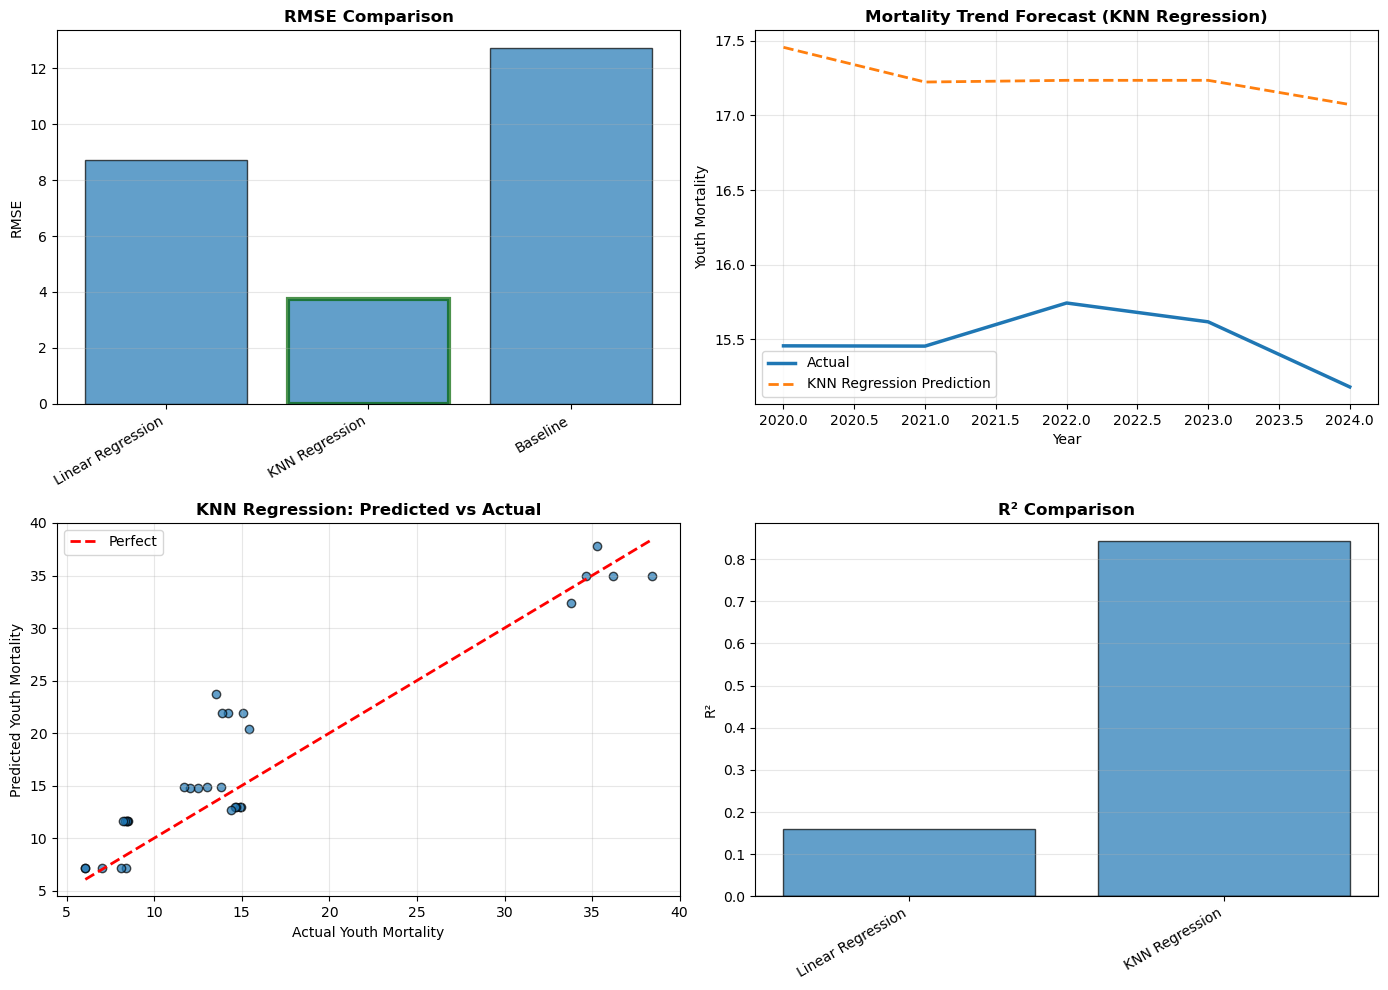

Saved: timeseries_results.png


In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) RMSE comparison
ax = axes[0, 0]

models_ts = list(ts_results.keys()) + ["Baseline"]
rmse_vals = [ts_results[m]["RMSE"] for m in ts_results.keys()] + [rmse_baseline]

bars = ax.bar(range(len(models_ts)), rmse_vals, alpha=0.7, edgecolor="black")

best_idx = rmse_vals.index(min(rmse_vals))
bars[best_idx].set_edgecolor("darkgreen")
bars[best_idx].set_linewidth(3)

ax.set_xticks(range(len(models_ts)))
ax.set_xticklabels(models_ts, rotation=30, ha="right")
ax.set_title("RMSE Comparison", fontweight="bold")
ax.set_ylabel("RMSE")
ax.grid(alpha=0.3, axis="y")


# 2) Time trend plot
ax = axes[0, 1]

plot_df = test_ts.copy()
plot_df["Predicted"] = ts_results[best_ts]["pred"]

trend_actual = plot_df.groupby("Year")["mort_median_5_24"].mean()
trend_pred = plot_df.groupby("Year")["Predicted"].mean()

ax.plot(trend_actual.index, trend_actual.values, label="Actual", linewidth=2.5)
ax.plot(trend_pred.index, trend_pred.values, label=f"{best_ts} Prediction", linestyle="--", linewidth=2)

ax.set_title(f"Mortality Trend Forecast ({best_ts})", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Youth Mortality")
ax.legend()
ax.grid(alpha=0.3)


# 3) Predicted vs Actual
ax = axes[1, 0]

ax.scatter(y_test, ts_results[best_ts]["pred"], alpha=0.7, edgecolor="black")

min_val = min(y_test.min(), ts_results[best_ts]["pred"].min())
max_val = max(y_test.max(), ts_results[best_ts]["pred"].max())

ax.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="Perfect")

ax.set_xlabel("Actual Youth Mortality")
ax.set_ylabel("Predicted Youth Mortality")
ax.set_title(f"{best_ts}: Predicted vs Actual", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)


# 4) R2 comparison
ax = axes[1, 1]

r2_vals = [ts_results[m]["R2"] for m in ts_results.keys()]

ax.bar(range(len(ts_results)), r2_vals, alpha=0.7, edgecolor="black")
ax.set_xticks(range(len(ts_results)))
ax.set_xticklabels(list(ts_results.keys()), rotation=30, ha="right")
ax.set_title("R² Comparison", fontweight="bold")
ax.set_ylabel("R²")
ax.axhline(0, color="black", linewidth=1)
ax.grid(alpha=0.3, axis="y")


plt.tight_layout()
plt.savefig("timeseries_results.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: timeseries_results.png")

The time-based regression analysis shows that the KNN model outperforms Linear Regression and the baseline model, achieving the lowest RMSE and highest R².
While the model successfully captures the overall trend in youth mortality over time, it tends to smooth out year-to-year fluctuations and struggles with extreme values.
The predicted vs actual plot indicates reasonable alignment along the diagonal, though errors increase for higher mortality levels.
Overall, the results suggest that non-linear models like KNN are better suited for capturing complex relationships in mortality data.